In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import sparse, linalg
from scipy.io import loadmat,savemat
from math import factorial

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk
from sklearn.decomposition import SparsePCA
# from scipy.io import loadmat
import matplotlib as mpl
from matplotlib.colors import ListedColormap
# Seaborn colormap
import seaborn as sns
import colorcet as cc
sns_list = sns.color_palette(cc.glasbey,n_colors=20).as_hex()
sns_list.pop(4)

# sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)
cm = sns_cmap

sns_list_balance_models = sns_list.copy()

sns_list_balance_models.insert(0, '#ffffff')  # Insert white at zero position
sns_list_balance_models.pop(1)
sns_cmap_balance_models = ListedColormap(sns_list_balance_models)

cm_balance_models = sns_cmap_balance_models

import jax.numpy as jnp
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.scipy.signal import fftconvolve
from jax.scipy.interpolate import RegularGridInterpolator
import math
import time
import pickle

cm = sns_cmap
  
mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']


# This code can be run to generate results for pointwise baseline for PIV Wavy Channel flow in the paper

Note that GMM cluster labels, loaded below, were generated using the implementation in "../GenDBTrialData/Gen_GMMs_Pointwise_Baseline_WavyChannelPIV.py".

In [2]:
labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$',
        r'$\nu \nabla \bar{\bf{u}}$',
        r'$\overline{({u^\prime} ^2)}_x$', r'$\overline{(u^\prime v^\prime)}_y$']

In [3]:
NU = 1.562e-5 # at 25 degree 
Re_bulk = 1/(NU)

In [4]:
# load wavy wall data generated on the instutute lambda
load_dir = '../GenDBTrialData/results/'

nc = 11
nfeatures=5

cluster_idx = np.load(load_dir + 'nc11/trial0/cluster_idx.npy')
cluster_idx_im = np.load(load_dir + 'nc11/trial0/cluster_idx_im.npy')

# also load grid + features
# also load grid + features
xx = np.load('../GenDBTrialData/results/terms/xx.npy')
yy = np.load('../GenDBTrialData/results/terms/yy.npy')
mask_weak = np.load('../GenDBTrialData/mask_weak.npy')
mask_weak_bool = np.load('../GenDBTrialData/mask_weak_bool.npy')

ux = np.load('../GenDBTrialData/results/terms/ux.npy').reshape(mask_weak_bool.shape,order='F')
uy = np.load('../GenDBTrialData/results/terms/uy.npy').reshape(mask_weak_bool.shape,order='F')
lap_u = np.load('../GenDBTrialData/results/terms/lap_u.npy').reshape(mask_weak_bool.shape,order='F')
Ruux = np.load('../GenDBTrialData/results/terms/Ruux.npy').reshape(mask_weak_bool.shape,order='F')
Ruvy = np.load('../GenDBTrialData/results/terms/Ruvy.npy').reshape(mask_weak_bool.shape,order='F')

vel_u_trunc = np.load('../GenDBTrialData/results/terms/vel_u_trunc.npy')
vel_v_trunc = np.load('../GenDBTrialData/results/terms/vel_v_trunc.npy')

UU_x = vel_u_trunc * ux
VU_y = vel_v_trunc * uy

UU_x = jnp.where(mask_weak==0, np.nan, UU_x)

VU_y = jnp.where(mask_weak==0, np.nan, VU_y)

nu_lap_U = (1/Re_bulk)*jnp.where(mask_weak==0, np.nan, lap_u)

Ruux = jnp.where(mask_weak==0, np.nan, Ruux)

Ruvy = jnp.where(mask_weak==0, np.nan, Ruvy)


features = np.array([UU_x[mask_weak_bool],
                    VU_y[mask_weak_bool],
                    nu_lap_U[mask_weak_bool],
                    Ruux[mask_weak_bool],
                    Ruvy[mask_weak_bool]]).T


y_cutoff = 720

nx = xx.size
ny = yy.size

In [7]:

def test_alpha_sPCA_GMM_model(alphas, features,cluster_idx,cluster_idx_to_test,nfeatures=6):
    err = np.zeros([len(alphas)])  # Error defined as norm of inactive terms
    sparsity = np.zeros([len(alphas)])
    for k in range(len(alphas)):
        i = cluster_idx_to_test
        # Identify points in the field corresponding to each cluster
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alphas[k])
        spca.fit(cluster_features)
        active_terms = np.nonzero(spca.components_[0])[0]
        inactive_terms = [feat for feat in range(nfeatures) if feat not in active_terms ]

        err[k] += np.linalg.norm(cluster_features[:, inactive_terms])

    return err

In [8]:
cluster_err = []
alphas = 50*np.array([0.1,0.175,0.25,0.375,0.5,0.625,0.75,0.875,1,5,6,7,10,15,20,25,27.5,30,40,50,60,70,80,90,100,120,140,145,150,160,200,220,240,250,300,500,750,1000])

for i in range(nc):
    cluster_err.append(test_alpha_sPCA_GMM_model(alphas, features, cluster_idx-1, i, nfeatures=5))

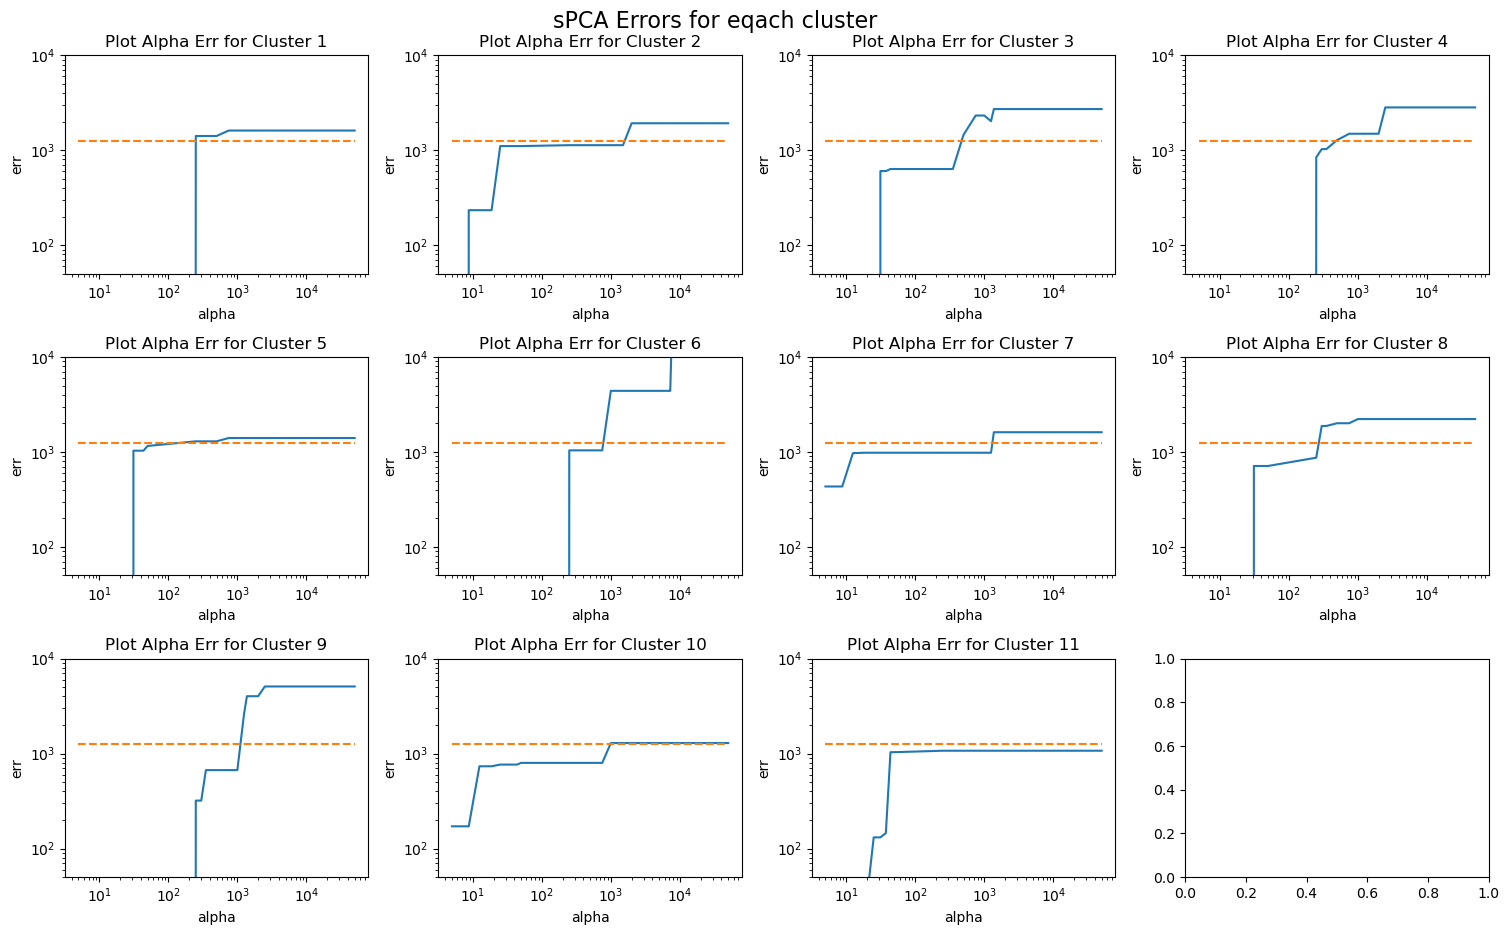

In [9]:
# Create figure and axes with 3x3 subplots, sharing the x-axis
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plotting
for i in range(nc):
    axes[i].loglog(alphas, cluster_err[i])
    axes[i].loglog(alphas, 1250 * np.ones_like(np.array(alphas)), linestyle='--')
    axes[i].set_title(f'Plot Alpha Err for Cluster {i + 1}')
    # if i == 2:
    axes[i].set_ylim(50,1e4)
    axes[i].set_xlabel('alpha')
    axes[i].set_ylabel('err')

# # Add shared x-label and y-label
# fig.text(0.5, 0.04, 'X Axis', ha='center')
# fig.text(0.04, 0.5, 'Y Axis', va='center', rotation='vertical')

# Adjust layout
plt.tight_layout(rect=[0.05, 0.05, 1, 0.97])
plt.suptitle("sPCA Errors for eqach cluster", fontsize=16)
plt.show()

In [10]:
def train_sPCA_model_multi_alpha(opt_alpha_list, features, nfeatures, nc, cluster_idx):
    spca_model = np.zeros([nc, nfeatures])
    for i in range(nc):
        alpha_opt = opt_alpha_list[i]
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alpha_opt)
        spca.fit(cluster_features)
        # print('GMM Cluster {0}:'.format(i))
        active_terms = np.nonzero(spca.components_[0])[0]
        if len(active_terms)>0:
            # print([labels[k] for k in active_terms])
            spca_model[i, active_terms] = 1  # Set to 1 for active terms in model
        else: print('None')

    return spca_model

In [11]:
# err_threshold = 145
err_threshold = 1250#500

alpha_opt = []
for i in range(nc):
    for j,err in enumerate(cluster_err[i]):
        if err > err_threshold:
            alpha_opt.append(alphas[j-1]) # append the last alpha value that was not above the error threshold
            break
        elif j == cluster_err[i].size - 1:
            alpha_opt.append(alphas[j-1]) # append the last alpha value if there are no alphas that surpass the error level
        else:
            continue

# print(alpha_opt)

In [12]:
optimal_alphas = alpha_opt
spca_model = train_sPCA_model_multi_alpha(optimal_alphas, features, nfeatures, nc, cluster_idx.flatten()-1)

balance_models, model_index = np.unique(spca_model, axis=0, return_inverse=True)

# print(balance_models)
nmodels = balance_models.shape[0]

balance_idx = np.array([model_index[i] for i in cluster_idx.flatten() - 1])

None


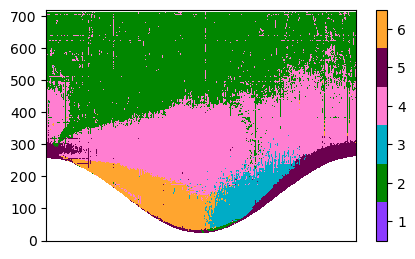

<Figure size 640x480 with 0 Axes>

In [13]:
cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = balance_idx
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))

# Save balance_model and balance maps & plot them too
plt.figure(figsize = (5,3))
plt.pcolormesh(xx[110:-60],yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,110:-60]+1, cmap = cm, vmin=-0.5, vmax=cm.N-0.5) # truncate the extra parts of the domain from neighboring humps
plt.colorbar(boundaries=np.arange(0.5, int(nmodels)+1.5), ticks=np.arange(1, int(nmodels)+2))
plt.gca().set_xticks([])
# plt.gca().set_yticks([])
# plt.savefig(f'PIV_sPCA_ClusterDomain,nc{nc}', transparent=True)
plt.show()
plt.clf()

In [ ]:
# np.save('../post_sPCA_arrays/cluster_idx_to_fill_PIV.npy',cluster_idx_to_fill)

# Note the outlying lack of RS in the blue and burgundy regions

Only unclear point is whether the viscous term near the wall isthe true dynamics or due to amplified noise, particular in back/forward finite difference at the walls. 

Important to note is the amount of truncation of the domain near the boundary depending on whether weak or pointwise is used. One downside of averaging across a sub-volume of the flow domain is that there is some region near the wall which cannot be accurately calculated. The to accurately converge, the weak form truncated ~20 pixels near the wall, whereas the finite difference method truncates only ~4 pixels that contain erroneous calculations. Authors of the dataset note that the viscous sublayer was resolved up to 14 pixels (which is a surprisingly large number of pixels, as a sidenote), which puts it in the range of truncation with the pointwise form, yet out of the range of the weak form, which could help explain this discrepancy.

Finally, while it is plausible that the viscous terms could be a valid inclusion for these two regions since they border the wall, it is important to note that the viscous term is unlikely to be a driving factor of the dynamics through out the entirety of the recirculation cluster, especially in the part of the region far away from the wall. It is further important to note that the Reynolds stress term is a driving term in the shear layer, recirculation and attached/detached regions, which is much better captured by the weak form, yet missed by the original method.


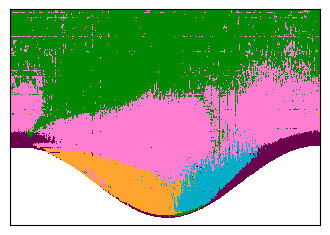

<Figure size 640x480 with 0 Axes>

In [14]:
cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = balance_idx
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))[:y_cutoff-5,:]

cm.set_bad('white')

# Save balance_model and balance maps & plot them too
fig = plt.figure(figsize = (4,2.8))
plt.pcolormesh(xx[22:-22],yy[:y_cutoff-5], cluster_idx_to_fill[:,22:-22]+1, cmap = cm, vmin=-0.5, vmax=cm.N-0.5)

plt.xticks([])
plt.yticks([])
plt.ylim(0,np.max(yy[:y_cutoff-5]))
plt.gca().set_facecolor('white')
# Transparent OUTSIDE axes/domain
fig.patch.set_alpha(0)

plt.savefig(f'sPCA_ClusterDomain_WW_PIV_Pointwise.png',bbox_inches='tight',transparent=True)
plt.show()
plt.clf()

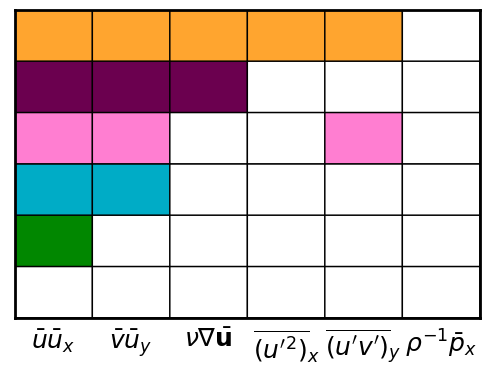

<Figure size 640x480 with 0 Axes>

In [46]:
'''Recreate with the pressure column!!'''
# Plot a grid with active terms in each cluster
gridmap = balance_models.copy()
gridmask = gridmap==0
gridmap = (gridmap.T*np.arange(nmodels)).T+1  # Scale map so that active terms can be color-coded
gridmap[gridmask] = 0

gridmap_added_pressure = np.vstack([gridmap.T, np.zeros(gridmap.shape[0])]).T

# NOTE We're skipping the deleting of unidentified terms because I need to count terms correctly identified as 0 in my quantitative metric
# plot spca_model matrix
# Delete zero terms
# grid_mask = np.nonzero( np.all(gridmap==0, axis=0) )[0]
# gridmap = np.delete(gridmap, grid_mask, axis=1)
# grid_labels = np.delete(labels, grid_mask)

grid_labels_pressure = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$',
                    r'$\nu \nabla \bar{\bf{u}}$', 
                    r'$\overline{({u^\prime} ^2)}_x$', r'$\overline{(u^\prime v^\prime)}_y$', r'$\rho^{-1} \bar{p}_x$']

plt.figure(figsize=(6, 4))
plt.pcolor(gridmap_added_pressure, vmin=-0.5, vmax=cm.N-0.5, cmap=cm_balance_models, edgecolors='k', linewidth=1)
plt.gca().set_xticks(np.arange(0.5, gridmap_added_pressure.shape[1]+0.5))
plt.gca().set_xticklabels(grid_labels_pressure, fontsize=18)
plt.gca().set_yticklabels([])

for axis in ['top','bottom','left','right']:
    plt.gca().spines[axis].set_linewidth(2)

plt.gca().tick_params(axis='both', width=0)
plt.savefig(f'sPCA_Matrix_Model_WW_PIV_Pointwise.png',bbox_inches='tight',transparent=True)
plt.show()
plt.clf()

# save cluster_idx np array and spca_model np
# np.save(save_dir + f'trial{i}/spca_model.npy', balance_models)
# np.save(save_dir + f'trial{i}/cluster_idx.npy', balancemap)

In [15]:
cmin = -20
cmax = 20
clim = 2

# Plot Eqn Space

In [16]:
labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$',
        r'$\nu \nabla \bar{\bf{u}}$',
        r'$\overline{({u^\prime} ^2)}_x$', r'$\overline{(u^\prime v^\prime)}_y$',r'$\rho^{-1} \bar{p}_x$']

In [17]:
cmap = plt.colormaps['RdBu'].copy()
cmap.set_bad('white')

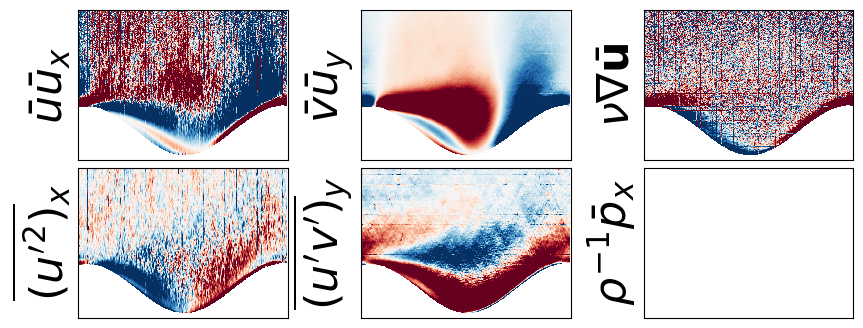

In [21]:
# Plot all six terms in the RANS equation
fig = plt.figure(figsize=(10, 4))
# labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$', r'$\rho^{-1} \bar{p}_x$',
#           r'$\nu \nabla^2 \bar{u}$', r'$\overline{(u^\prime v^\prime)}_y$', r'$\overline{({u^\prime} ^2)}_x$']
# clim = 9e-1
fontsize=32

plt.subplot(231)
cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = features[:,0]
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))
plt.pcolormesh(xx,yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,:], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[0], fontsize=fontsize)

plt.subplot(232)
# field = features[:,1]
cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = features[:,1]
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))
plt.pcolormesh(xx,yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,:], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[1], fontsize=fontsize)

plt.subplot(233)
# field = features[:,2]
cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = features[:,2]
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))
plt.pcolormesh(xx,yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,:], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[2], fontsize=fontsize)

plt.subplot(234)
# field = features[:,3]
cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = features[:,3]
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))
plt.pcolormesh(xx,yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,:], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[3], fontsize=fontsize)

plt.subplot(235)
# field = features[:,4]
cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = features[:,4]
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))
plt.pcolormesh(xx,yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,:], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[4], fontsize=fontsize)

plt.subplot(236)
# field = features[:,5]
# cluster_idx_to_fill = cluster_idx_im.copy().flatten()
# indices = np.where(~np.isnan(cluster_idx_to_fill))
# cluster_idx_to_fill[indices] = features[:,5]
# cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))
# plt.pcolormesh(xx,yy[:y_cutoff], cluster_idx_to_fill[:y_cutoff,:], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.gca().set_facecolor('white')
plt.gca().patch.set_alpha(1.0)
plt.ylabel(labels[5], fontsize=fontsize)

fig.patch.set_alpha(0)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.35, hspace=0.05)

plt.savefig('PIVWavyWall_Pointwise_Terms_PressLast.png', dpi=480)

plt.show()